<a href="https://colab.research.google.com/github/GouseMohid/Gouse-Innolift-projects/blob/main/Comparison%20of%20algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NAIVE BAYES CLASSIFIER  For Product Review sentiment analyzer-Ecommerce


## M1: Load 10K Amazon reviews, text cleaning, NLTK stopwords, explore rating distribution

In [22]:
import pandas as pd
import re
import nltk

# Download NLTK data (only needs to be run once)
nltk.download('stopwords')
nltk.download('wordnet')

# Now import after download to ensure resources are available
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load the dataset
df = pd.read_csv('/content/amazon_reviews.csv')

# Display the first few rows and info to understand the data structure
print("Dataset Head:")
display(df.head())
print("\nDataset Info:")
df.info()

Dataset Head:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Unnamed: 0,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,Positive,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,Negative,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,Positive,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,Negative,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,Positive,1350777600,Great taffy,Great taffy at a great price. There was a wid...



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              10000 non-null  int64 
 1   Id                      10000 non-null  int64 
 2   ProductId               10000 non-null  object
 3   UserId                  10000 non-null  object
 4   ProfileName             9999 non-null   object
 5   HelpfulnessNumerator    10000 non-null  int64 
 6   HelpfulnessDenominator  10000 non-null  int64 
 7   Score                   10000 non-null  object
 8   Time                    10000 non-null  int64 
 9   Summary                 10000 non-null  object
 10  Text                    10000 non-null  object
dtypes: int64(5), object(6)
memory usage: 859.5+ KB


### Text Cleaning and Preprocessing

In [23]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return ""
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(words)

# Apply preprocessing to the 'Text' column (corrected from 'review_text')
df['cleaned_review_text'] = df['Text'].apply(preprocess_text)

print("Original vs Cleaned Review Text (first 5 rows):")
display(df[['Text', 'cleaned_review_text']].head())

Original vs Cleaned Review Text (first 5 rows):


,Text,cleaned_review_text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


### Explore Rating Distribution and Sentiment Mapping

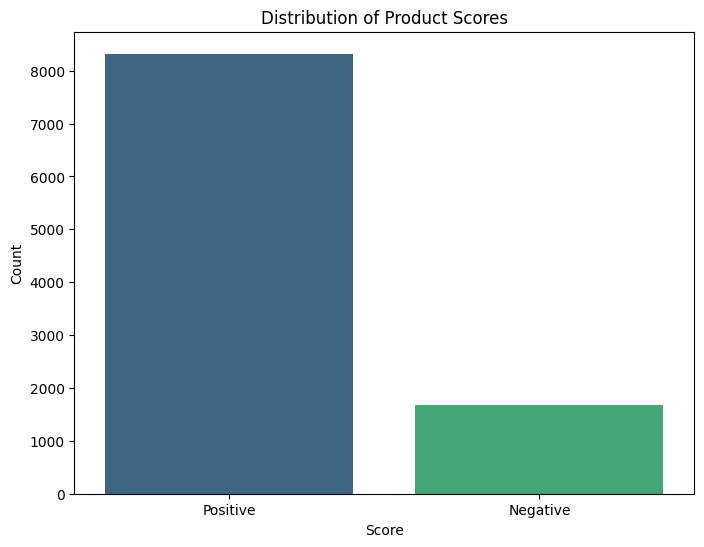

Sentiment Distribution:


,count
sentiment,
positive,8321
negative,1679


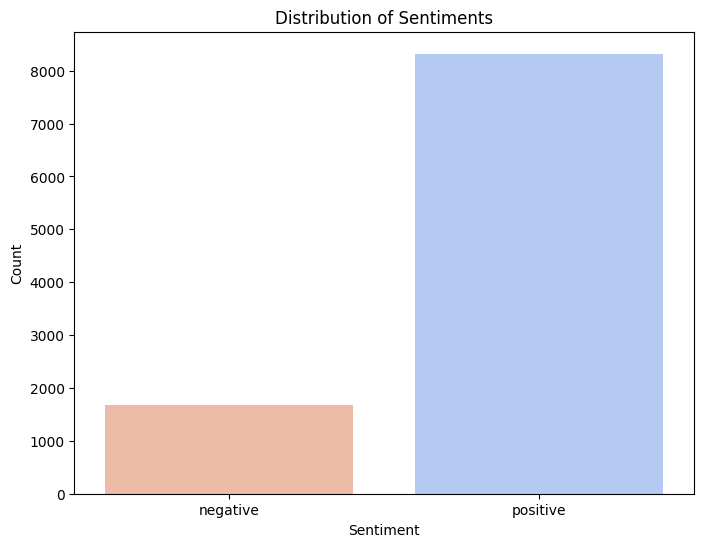

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of Scores (Positive/Negative)
plt.figure(figsize=(8, 6))
sns.countplot(x='Score', data=df, palette='viridis', hue='Score', legend=False) # Use 'Score' column directly
plt.title('Distribution of Product Scores') # Changed title to reflect 'Score'
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# Define sentiment mapping based on the 'Score' column
# Since the 'Score' column only has 'Positive' and 'Negative',
# we will map directly to 'positive' and 'negative' sentiment.
# The 'neutral' category is not directly available from this column and would require further definition.
def map_sentiment_from_score(score_text):
    if score_text == 'Positive':
        return 'positive'
    elif score_text == 'Negative':
        return 'negative'
    else:
        return 'unknown' # Handle any unexpected values if they exist

df['sentiment'] = df['Score'].apply(map_sentiment_from_score)

print("Sentiment Distribution:")
display(df['sentiment'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='coolwarm', order=['negative', 'positive'], hue='sentiment', legend=False) # Removed 'neutral' from order
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## M2: TF-IDF vectorizer, Naive Bayes, Positive/Neutral/Negative output

### Split Data into Training and Testing Sets

In [25]:
from sklearn.model_selection import train_test_split

# Define sentiment mapping based on the 'Score' column
# This is added here defensively in case previous cells were not run,
# ensuring the 'sentiment' column exists for data splitting.
def map_sentiment_from_score(score_text):
    if score_text == 'Positive':
        return 'positive'
    elif score_text == 'Negative':
        return 'negative'
    else:
        return 'unknown'

# Ensure 'sentiment' column exists before proceeding
if 'sentiment' not in df.columns:
    df['sentiment'] = df['Score'].apply(map_sentiment_from_score)

X = df['cleaned_review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print("\nSentiment distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nSentiment distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set size: 8000 samples
Test set size: 2000 samples

Sentiment distribution in training set:
sentiment
positive    0.832125
negative    0.167875
Name: proportion, dtype: float64

Sentiment distribution in test set:
sentiment
positive    0.832
negative    0.168
Name: proportion, dtype: float64


### TF-IDF Vectorizer

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (8000, 5000)
Shape of X_test_tfidf: (2000, 5000)


### Train and Evaluate Naive Bayes Classifier

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate the Naive Bayes model
print("Naive Bayes Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classifier Performance:
Accuracy: 0.8390

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.05      0.09       336
    positive       0.84      1.00      0.91      1664

    accuracy                           0.84      2000
   macro avg       0.86      0.52      0.50      2000
weighted avg       0.85      0.84      0.77      2000



### Train and Evaluate Logistic Regression Classifier (for comparison)

In [28]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# Using 'lbfgs' solver and increased max_iter for convergence
lr_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate the Logistic Regression model
print("Logistic Regression Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classifier Performance:
Accuracy: 0.8815

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.33      0.48       336
    positive       0.88      0.99      0.93      1664

    accuracy                           0.88      2000
   macro avg       0.89      0.66      0.71      2000
weighted avg       0.88      0.88      0.86      2000



### Model Comparison and Best Model Selection

In [29]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

if nb_accuracy > lr_accuracy:
    best_model = "Naive Bayes"
    best_accuracy = nb_accuracy
else:
    best_model = "Logistic Regression"
    best_accuracy = lr_accuracy

print(f"\nBased on accuracy, the {best_model} model is better suited for this project with an accuracy of {best_accuracy:.4f}.")

# Saving the best model and vectorizer (conceptual step)
# import pickle
# with open('tfidf_vectorizer.pkl', 'wb') as f:
#     pickle.dump(tfidf_vectorizer, f)
# print("TF-IDF Vectorizer saved as tfidf_vectorizer.pkl")

# if best_model == "Naive Bayes":
#     with open('naive_bayes_model.pkl', 'wb') as f:
#         pickle.dump(nb_model, f)
#     print("Naive Bayes model saved as naive_bayes_model.pkl")
# else:
#     with open('logistic_regression_model.pkl', 'wb') as f:
#         pickle.dump(lr_model, f)
#     print("Logistic Regression model saved as logistic_regression_model.pkl")

Naive Bayes Accuracy: 0.8390
Logistic Regression Accuracy: 0.8815

Based on accuracy, the Logistic Regression model is better suited for this project with an accuracy of 0.8815.
